# Exploratory Data Analysis

## Descripción General

En este documento buscámos entender los datos que tenemos a nuestra disposición, para predecir que clientes se subscribirán a un déposito a plazos. Queremos entender la estructura del dataset y  la calidad de los datos para prepararnos para el pre-procesado.

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from IPython.display import display


def nl():
    print('\n')


for f in os.listdir('../data'):
    print(f.ljust(30) + str(round(os.path.getsize('../data/' + f) / 1000000, 2)) + 'MB')

bank_competition_14.pkl       0.01MB
bank_14.pkl                   0.93MB


Podemos observar que tenemos dos datasets, bank_14.pkl lo usaremos para entrenar y bank_competition_14.pkl para probar.

## Carga de Data y Visión Géneral

El objetivo ahora es entender la estructura géneral de los datos y tener una idea inicial de la forma de nuestros datasets.

In [50]:
df_train = pd.read_pickle('../data/bank_14.pkl')
df_test = pd.read_pickle('../data/bank_competition_14.pkl')

nl()
print('Tamaño de train: ', str(df_train.shape))
print('Tamaño de test: ', str(df_test.shape))
print('Columnas: ', str(df_train.columns.values.tolist()))



Tamaño de train:  (11000, 17)
Tamaño de test:  (162, 16)
Columnas:  ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


La variable objetivo es **deposit**. Podemos observar que hay 16 features aparte de nuestro objetivo, tenemos 11000 datos de entrenamiento y 162 para hacer testing. Más adelante exploraremos todas las variables a mayor detalle.

## Análisis de la Variable Objetivo

Empecemos por observar la distribución de los datos.

object


,Class,Count,Percentage
0,no,5780,52.545455
1,yes,5220,47.454545


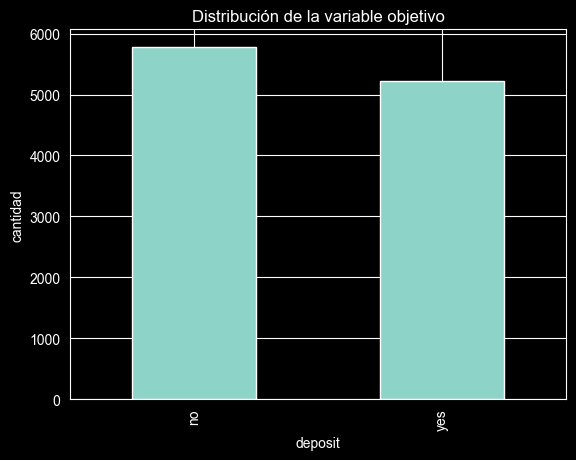

In [35]:
target = df_train['deposit'].tolist()

print(df_train['deposit'].dtype)


def label_plot(title, x, y):
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)


summary = pd.DataFrame({
    "Class": df_train['deposit'].value_counts().index,
    "Count": df_train['deposit'].value_counts().values,
    "Percentage": df_train['deposit'].value_counts(normalize=True).values * 100
})

display(summary)

df_train["deposit"].value_counts().plot(kind="bar")
label_plot('Distribución de la variable objetivo', 'deposit', 'cantidad')
plt.show()

La variable deposit presenta dos clases "yes" y "no", por lo que el problema es de clasificación binaria. La clases mayoritaria es "no", representando 52.54% de las instancias, mientras que "yes" representa el 47.45%. Por tanto, el conjunto de datos presenta un desbalance leve, que tendrá que tomarse en cuenta durante la evaluación de modelos.

## Esquema de Variables


In [53]:
summary = pd.DataFrame({
    "Semantic Type": df_train.dtypes,
    "Role": ["target" if col == "deposit" else "feature" for col in df_train.columns],
    "Missing": df_train.isnull().sum(),
    "Missing %": (df_train.isnull().mean() * 100).round(2).values,
    "Unique Values": df_train.nunique(dropna=True).tolist(),
    "Sample Values": [", ".join(map(str, df_train[col].dropna().unique()[:4])) for col in df_train.columns],

})

display(summary)

type_summary = (
    summary["Semantic Type"]
    .value_counts()
    .reset_index(name="Count")
)

display(type_summary)

,Semantic Type,Role,Missing,Missing %,Unique Values,Sample Values
age,int64,feature,0,0.00,76,"59, 56, 41, 55"
job,object,feature,174,1.58,12,"admin., technician, services, management"
marital,object,feature,340,3.09,3,"married, single, divorced"
education,object,feature,0,0.00,4,"secondary, tertiary, primary, unknown"
default,object,feature,0,0.00,2,"no, yes"
balance,int64,feature,0,0.00,3783,"2343, 45, 1270, 2476"
housing,object,feature,0,0.00,2,"yes, no"
loan,object,feature,0,0.00,2,"no, yes"
contact,object,feature,0,0.00,3,"unknown, cellular, telephone"
day,int64,feature,0,0.00,31,"5, 6, 7, 8"


,Semantic Type,Count
0,object,10
1,int64,7


Podemos observar que las 16 features se dividen en variables categóricas y numéricas. La mayoría no tiene valores nulos, aunque job y marital si, las exploraremos más adelante. Algunas variables requieren tratamiento semántico especial, como pdays, que incluye el valor -1 o variables categóricas binarias como default, housing y loan.

## Análisis de Variables

Ahora que vimos la estructura géneral de las variables, nos conviene indagar más a profundidad en ellas, para entender exactamente con que estamos tratando. Para esto, iremos por tipo, primero las categóricas, luego las númericas.

### Variables Categóricas

Nos interesa saber los dominios de cada variable, las distribuciones de valores en cada valor y por que hay valores faltantes en algunas de ellas.